In [1]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ===== LOAD DATA =====
df = pd.read_csv('Spotify-main/data_w_genres.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (28680, 16)

Columns: ['genres', 'artists', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'key', 'mode', 'count']

First 5 rows:


,genres,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,['show tunes'],"""Cats"" 1981 Original London Cast",0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9
1,[],"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26
2,[],"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7
3,[],"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27
4,[],"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7


In [5]:
# ===== DATA EXPLORATION =====
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Stats:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 28680 entries, 0 to 28679
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genres            28680 non-null  str    
 1   artists           28680 non-null  str    
 2   acousticness      28680 non-null  float64
 3   danceability      28680 non-null  float64
 4   duration_ms       28680 non-null  float64
 5   energy            28680 non-null  float64
 6   instrumentalness  28680 non-null  float64
 7   liveness          28680 non-null  float64
 8   loudness          28680 non-null  float64
 9   speechiness       28680 non-null  float64
 10  tempo             28680 non-null  float64
 11  valence           28680 non-null  float64
 12  popularity        28680 non-null  float64
 13  key               28680 non-null  int64  
 14  mode              28680 non-null  int64  
 15  count             28680 non-null  int64  
dtypes: float64(11), int64(3), str(2)
memo

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
count,28680.000000,28680.000000,2.868000e+04,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000
mean,0.498373,0.546490,2.388780e+05,0.497488,0.174756,0.202441,-11.140498,0.094014,115.844830,0.512723,34.060945,5.412901,0.759170,13.847211
std,0.370614,0.176474,1.211318e+05,0.254885,0.298406,0.140884,5.771749,0.111986,25.003834,0.244421,22.376438,3.480552,0.427595,53.372544
min,0.000000,0.000000,1.879550e+04,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.122296,0.431000,1.823304e+05,0.283568,0.000004,0.110362,-13.972292,0.039200,99.366500,0.329000,12.000000,2.000000,1.000000,2.000000
50%,0.478458,0.557000,2.186400e+05,0.504000,0.001880,0.161000,-10.088938,0.052200,115.357400,0.523243,39.000000,6.000000,1.000000,3.000000
75%,0.896000,0.675000,2.684670e+05,0.702783,0.215291,0.247000,-6.889000,0.095300,129.848750,0.703000,51.000000,8.000000,1.000000,8.000000
max,0.996000,0.986000,5.403500e+06,1.000000,1.000000,0.991000,1.342000,0.964000,217.743000,0.991000,93.000000,11.000000,1.000000,3169.000000


In [6]:
# ===== DATA CLEANING =====
# Drop duplicates
df = df.drop_duplicates()

# Drop missing values
df = df.dropna()

# Reset index
df = df.reset_index(drop=True)

print("✅ Clean dataset shape:", df.shape)
print("\nGenres in dataset:")
print(df['genres'].value_counts().head(10))

✅ Clean dataset shape: (28680, 16)

Genres in dataset:
genres
[]                                                                            9857
['movie tunes']                                                                 69
['show tunes']                                                                  63
['hollywood']                                                                   56
['orchestral performance']                                                      50
['broadway', 'hollywood', 'show tunes']                                         48
['disney', 'movie tunes']                                                       45
['sleep']                                                                       42
['gospel']                                                                      41
['contemporary country', 'country', 'country road', 'modern country rock']      41
Name: count, dtype: int64


In [7]:
# ===== FEATURE SELECTION =====
feature_cols = ['acousticness', 'danceability', 'energy', 
                'instrumentalness', 'liveness', 'loudness',
                'speechiness', 'tempo', 'valence', 'popularity']

X = df[feature_cols]

# Scale features 0 to 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled successfully!")
print("Feature matrix shape:", X_scaled.shape)

✅ Features scaled successfully!
Feature matrix shape: (28680, 10)


In [8]:
# ===== COSINE SIMILARITY =====
cosine_sim = cosine_similarity(X_scaled)

print("✅ Similarity matrix ready!")
print("Matrix shape:", cosine_sim.shape)

✅ Similarity matrix ready!
Matrix shape: (28680, 28680)


In [9]:
# ===== RECOMMENDATION FUNCTION =====
def recommend_songs(genre_name, n=10):
    # Filter by genre
    genre_df = df[df['genres'].str.contains(genre_name, case=False, na=False)]
    
    if genre_df.empty:
        print(f"❌ Genre '{genre_name}' not found!")
        return
    
    # Get index of first match
    idx = genre_df.index[0]
    
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    # Get song indices
    song_indices = [i[0] for i in sim_scores]
    
    result = df[['genres']].iloc[song_indices].copy()
    result['similarity_score'] = [round(i[1], 3) for i in sim_scores]
    
    print(f"✅ Top {n} recommendations for genre: '{genre_name}'")
    return result

# Test it!
recommend_songs('pop', n=10)

✅ Top 10 recommendations for genre: 'pop'


,genres,similarity_score
3714,[],0.999
11455,"['ccm', 'christian alternative rock', 'christi...",0.998
21219,['pop'],0.998
24189,"['alberta country', 'canadian contemporary cou...",0.998
21664,"['contemporary country', 'country', 'country d...",0.998
5084,"['outlaw country', 'red dirt', 'texas country']",0.997
3851,['celtic rock'],0.997
5987,[],0.997
8288,"['album rock', 'classic rock', 'hard rock', 'm...",0.997
5804,"['new wave pop', 'rock keyboard']",0.997


C:\Users\priya\AppData\Local\Temp\ipykernel_7872\3845255348.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


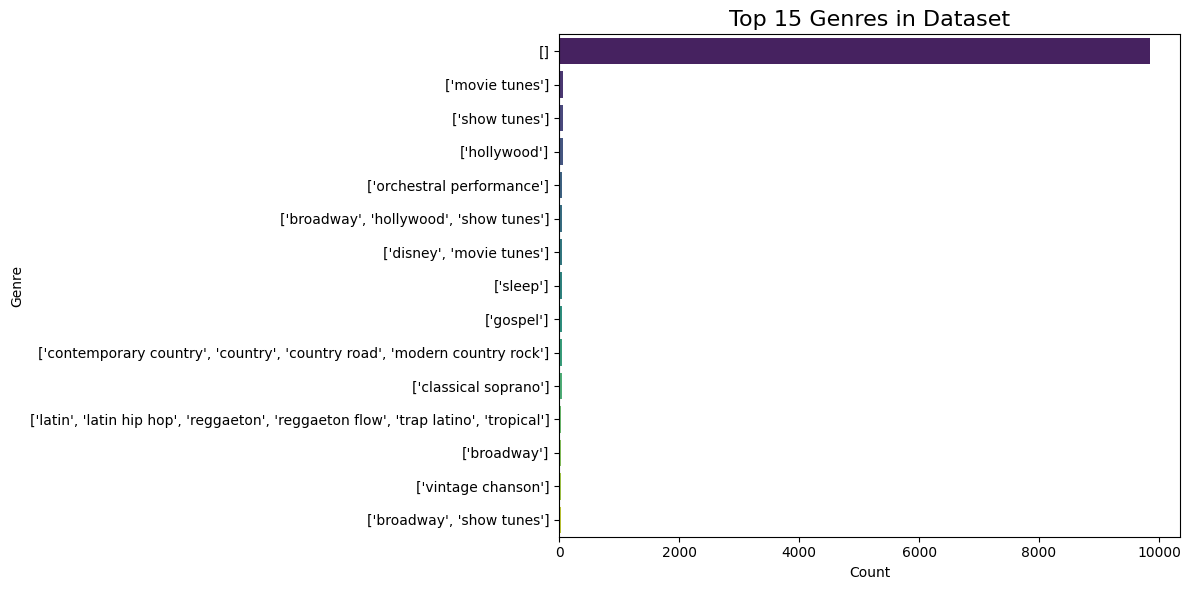

✅ Genre distribution plot saved!


In [10]:
# ===== GENRE DISTRIBUTION PLOT =====
plt.figure(figsize=(12, 6))
top_genres = df['genres'].value_counts().head(15)

sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 15 Genres in Dataset', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_distribution.png')
plt.show()

print("✅ Genre distribution plot saved!")

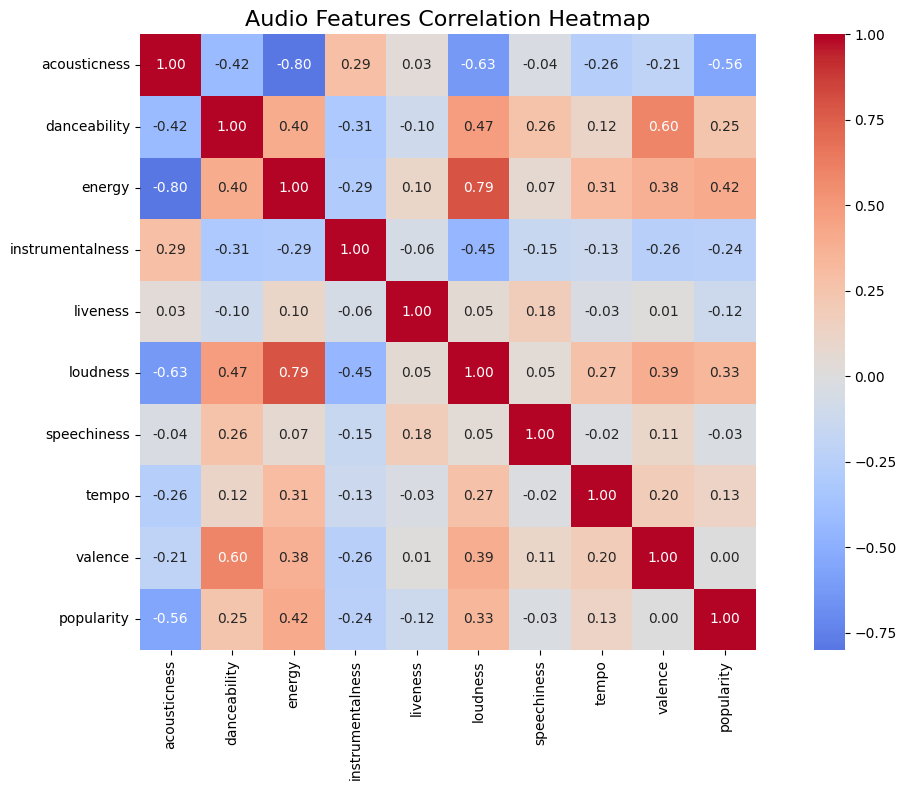

✅ Heatmap saved!


In [11]:
# ===== CORRELATION HEATMAP =====
plt.figure(figsize=(12, 8))

corr = df[feature_cols].corr()

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Audio Features Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print("✅ Heatmap saved!")

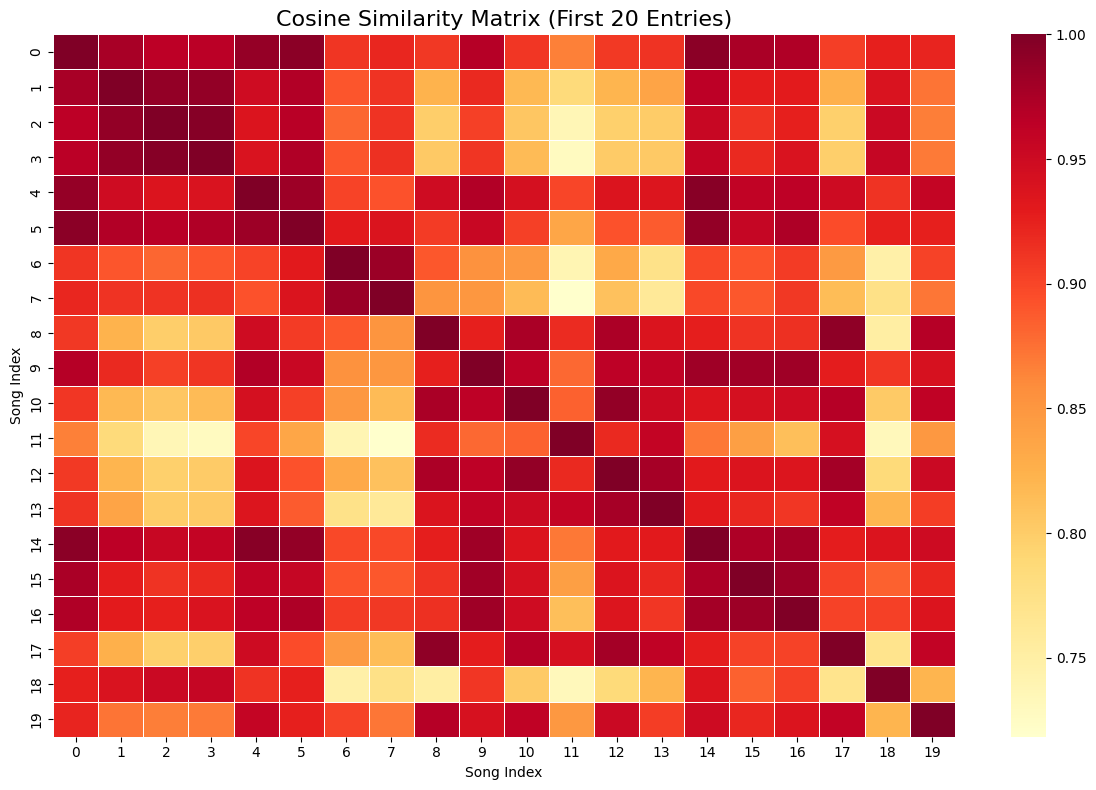

✅ Cosine similarity heatmap saved!


In [12]:
# ===== COSINE SIMILARITY HEATMAP =====
plt.figure(figsize=(12, 8))

# First 20 genres only (full matrix bohot bada hoga)
sim_df = pd.DataFrame(cosine_sim[:20, :20])

sns.heatmap(sim_df,
            cmap='YlOrRd',
            annot=False,
            linewidths=0.5)

plt.title('Cosine Similarity Matrix (First 20 Entries)', fontsize=16)
plt.xlabel('Song Index')
plt.ylabel('Song Index')
plt.tight_layout()
plt.savefig('cosine_sim.png')
plt.show()

print("✅ Cosine similarity heatmap saved!")

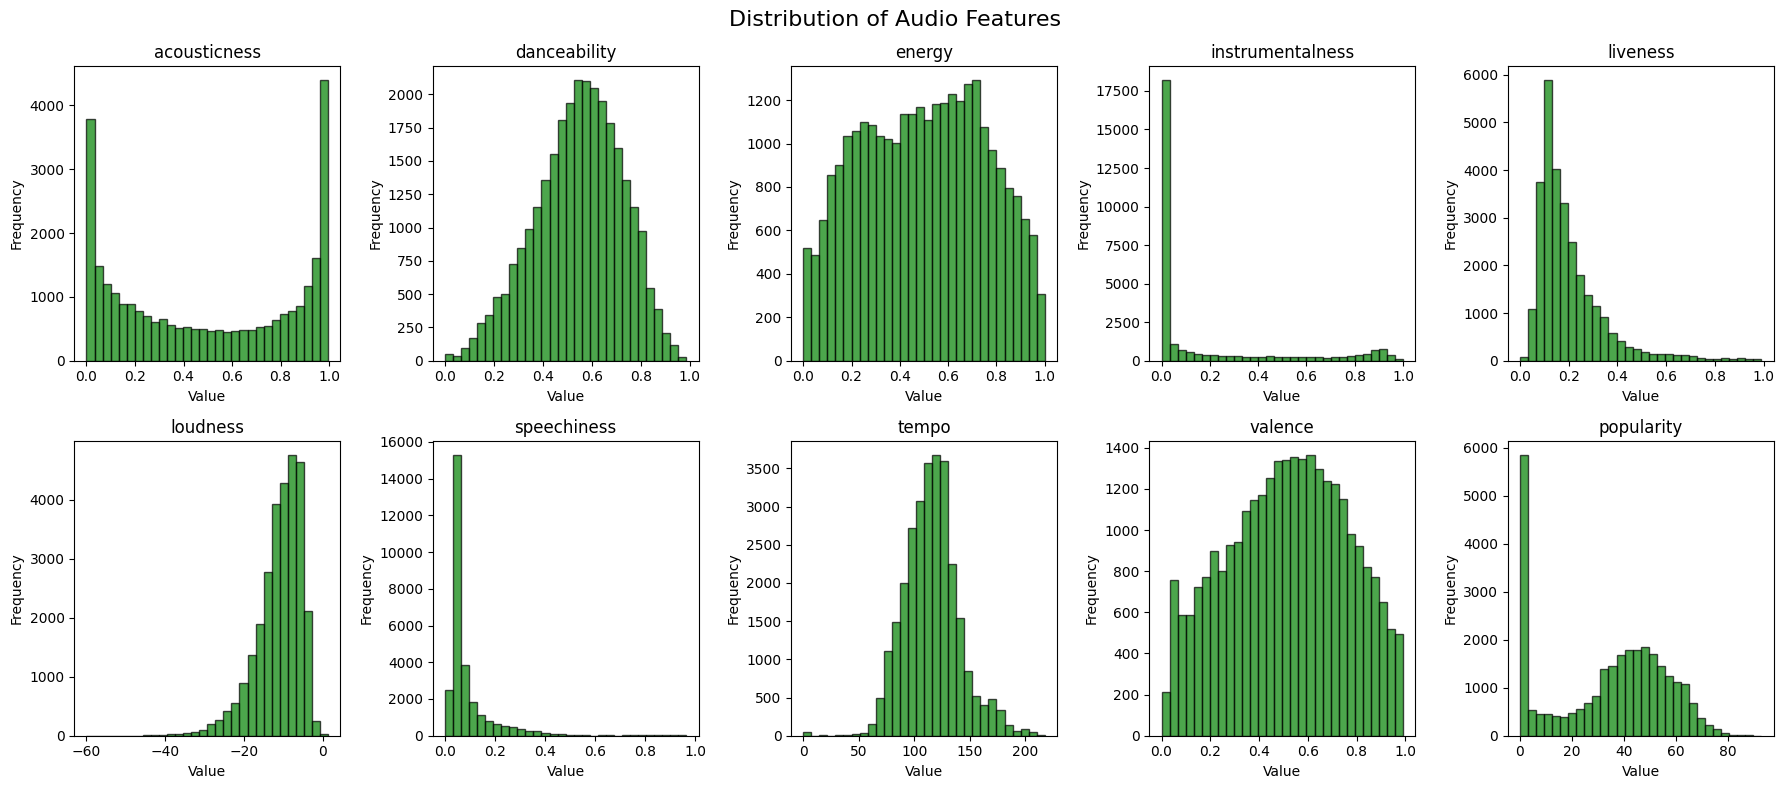

✅ Feature distribution plot saved!


In [13]:
# ===== AUDIO FEATURES DISTRIBUTION =====
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Audio Features', fontsize=16)
plt.tight_layout()
plt.savefig('feature_distribution.png')
plt.show()

print("✅ Feature distribution plot saved!")

C:\Users\priya\AppData\Local\Temp\ipykernel_7872\4178602328.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_popularity.values,


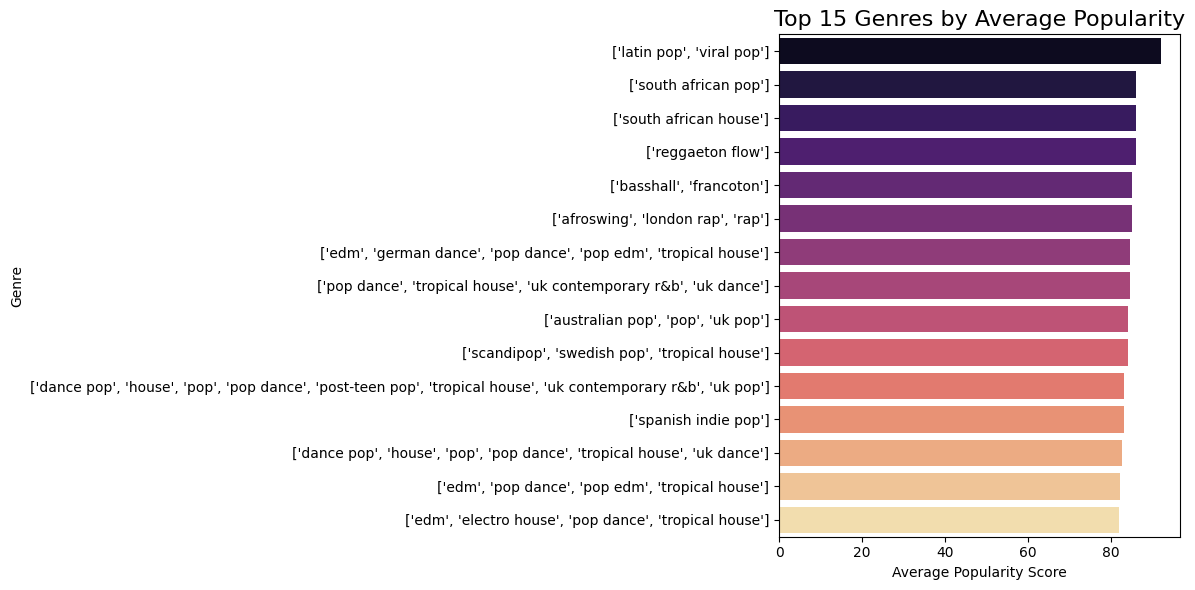

✅ Genre popularity plot saved!


In [14]:
# ===== TOP GENRES BY AVERAGE POPULARITY =====
genre_popularity = df.groupby('genres')['popularity'].mean()
genre_popularity = genre_popularity.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_popularity.values, 
            y=genre_popularity.index, 
            palette='magma')

plt.title('Top 15 Genres by Average Popularity', fontsize=16)
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_popularity.png')
plt.show()

print("✅ Genre popularity plot saved!")

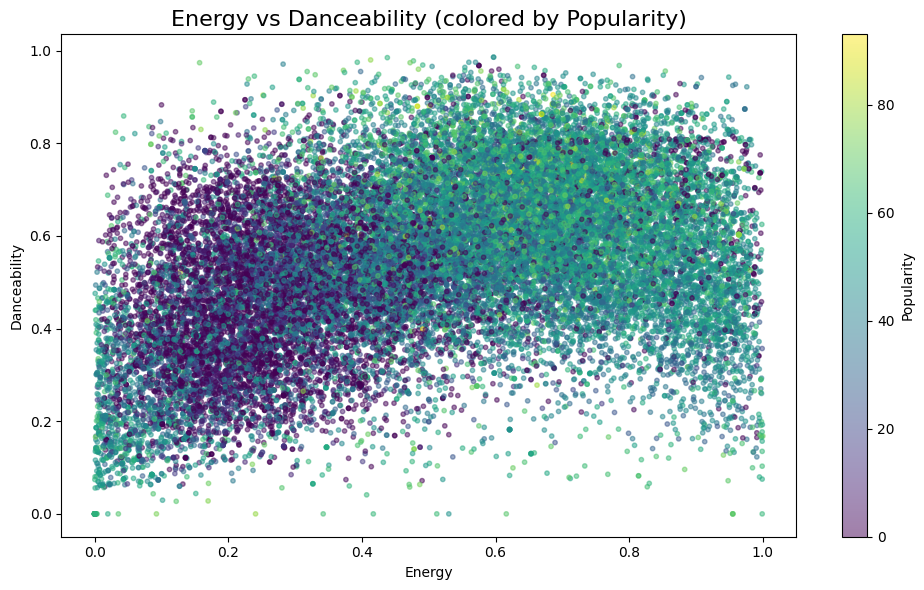

✅ Scatter plot saved!


In [15]:
# ===== ENERGY vs DANCEABILITY SCATTER PLOT =====
plt.figure(figsize=(10, 6))

scatter = plt.scatter(df['energy'], 
                      df['danceability'],
                      c=df['popularity'],
                      cmap='viridis',
                      alpha=0.5,
                      s=10)

plt.colorbar(scatter, label='Popularity')
plt.title('Energy vs Danceability (colored by Popularity)', fontsize=16)
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.tight_layout()
plt.savefig('energy_vs_danceability.png')
plt.show()

print("✅ Scatter plot saved!")

🎵 Finding top 10 recommendations for genre: 'pop'
✅ Top 10 recommendations for genre: 'pop'

📋 Recommended Genres & Similarity Scores:
                                                                                                                                            genres  similarity_score
3714                                                                                                                                            []             0.999
11455                                                                          ['ccm', 'christian alternative rock', 'christian music', 'worship']             0.998
21219                                                                                                                                      ['pop']             0.998
24189  ['alberta country', 'canadian contemporary country', 'canadian country', 'contemporary country', 'country', 'country dawn', 'country road']             0.998
21664                                   

C:\Users\priya\AppData\Local\Temp\ipykernel_7872\3082660673.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


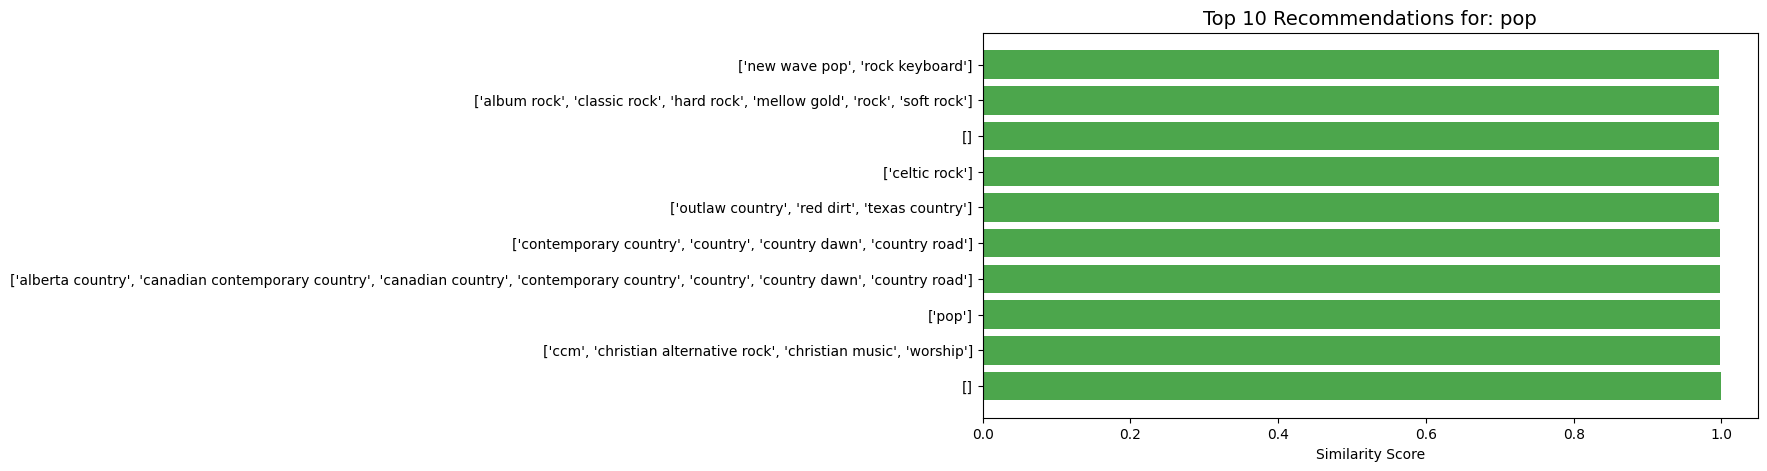

In [16]:
# ===== FINAL RECOMMENDATION SYSTEM TEST =====
def get_recommendations(genre, n=10):
    print(f"🎵 Finding top {n} recommendations for genre: '{genre}'")
    print("=" * 50)
    
    result = recommend_songs(genre, n)
    
    if result is not None:
        print("\n📋 Recommended Genres & Similarity Scores:")
        print(result.to_string())
        
        # Plot similarity scores
        plt.figure(figsize=(10, 5))
        plt.barh(range(len(result)), 
                 result['similarity_score'],
                 color='green',
                 alpha=0.7)
        plt.yticks(range(len(result)), result['genres'].values)
        plt.xlabel('Similarity Score')
        plt.title(f'Top {n} Recommendations for: {genre}', fontsize=14)
        plt.tight_layout()
        plt.savefig('recommendations.png')
        plt.show()

# Test with different genres
get_recommendations('pop', n=10)

In [17]:
# ===== PROJECT SUMMARY =====
print("=" * 60)
print("       SPOTIFY MUSIC RECOMMENDATION SYSTEM")
print("=" * 60)

print(f"\n📊 Dataset Statistics:")
print(f"   Total Records     : {df.shape[0]}")
print(f"   Total Features    : {df.shape[1]}")
print(f"   Unique Genres     : {df['genres'].nunique()}")

print(f"\n🎯 Features Used for Recommendation:")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")

print(f"\n🤖 Algorithm Used:")
print(f"   Content-Based Filtering")
print(f"   Cosine Similarity")

print(f"\n📈 Visualizations Generated:")
print(f"   1. Genre Distribution")
print(f"   2. Correlation Heatmap")
print(f"   3. Cosine Similarity Heatmap")
print(f"   4. Feature Distribution")
print(f"   5. Genre Popularity")
print(f"   6. Energy vs Danceability")
print(f"   7. Recommendations Chart")

print(f"\n✅ Project Complete!")
print("=" * 60)

       SPOTIFY MUSIC RECOMMENDATION SYSTEM

📊 Dataset Statistics:
   Total Records     : 28680
   Total Features    : 16
   Unique Genres     : 10743

🎯 Features Used for Recommendation:
   1. acousticness
   2. danceability
   3. energy
   4. instrumentalness
   5. liveness
   6. loudness
   7. speechiness
   8. tempo
   9. valence
   10. popularity

🤖 Algorithm Used:
   Content-Based Filtering
   Cosine Similarity

📈 Visualizations Generated:
   1. Genre Distribution
   2. Correlation Heatmap
   3. Cosine Similarity Heatmap
   4. Feature Distribution
   5. Genre Popularity
   6. Energy vs Danceability
   7. Recommendations Chart

✅ Project Complete!


In [2]:
# ===== LOAD SPOTIFYFEATURES DATASET =====
import pandas as pd

df2 = pd.read_csv('../SpotifyFeatures.csv')

print("Shape:", df2.shape)
print("\nColumns:", df2.columns.tolist())
print("\nFirst 5 rows:")
df2.head()

Shape: (232725, 18)

Columns: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']

First 5 rows:


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
# ===== SONG BASED RECOMMENDATION SYSTEM =====
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Clean data
df2 = df2.drop_duplicates(subset='track_name')
df2 = df2.dropna()
df2 = df2.reset_index(drop=True)

# Sample 5000 songs only (memory fix)
df2 = df2.sample(5000, random_state=42).reset_index(drop=True)

# Select features
song_features = ['popularity', 'acousticness', 'danceability', 
                 'energy', 'instrumentalness', 'liveness', 
                 'loudness', 'speechiness', 'tempo', 'valence']

X2 = df2[song_features]
scaler2 = MinMaxScaler()
X2_scaled = scaler2.fit_transform(X2)

# Cosine similarity
cosine_sim2 = cosine_similarity(X2_scaled)

print("✅ Song recommendation system ready!")
print("Total songs:", len(df2))

✅ Song recommendation system ready!
Total songs: 5000


In [5]:
# ===== SONG RECOMMENDATION FUNCTION =====
def recommend_by_song(song_name, n=10):
    # Search song in dataset
    matches = df2[df2['track_name'].str.contains(song_name, case=False, na=False)]
    
    if matches.empty:
        print(f"❌ Song '{song_name}' not found!")
        return
    
    # Get index
    idx = matches.index[0]
    found_song = df2.loc[idx, 'track_name']
    found_artist = df2.loc[idx, 'artist_name']
    
    print(f"🎵 Found: '{found_song}' by {found_artist}")
    print("=" * 50)
    
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim2[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    song_indices = [i[0] for i in sim_scores]
    
    result = df2[['track_name', 'artist_name', 'genre']].iloc[song_indices].copy()
    result['similarity_score'] = [round(i[1], 3) for i in sim_scores]
    result = result.reset_index(drop=True)
    
    print(f"\n🎶 Top {n} Similar Songs:")
    print(result.to_string())
    return result

# Test it!
recommend_by_song('Love', n=10)

🎵 Found: 'Love Me Now - Recorded at Spotify Studios NYC' by John Legend

🎶 Top 10 Similar Songs:
                               track_name          artist_name        genre  similarity_score
0                            Summer's End           John Prine  Alternative             0.996
1                   In The Silence - Demo            JP Cooper          R&B             0.995
2                            Chasing Cars     Sleeping At Last         Folk             0.992
3                         Girl - Acoustic                 SYML         Folk             0.992
4         La Vie En Rose - Single Version      Louis Armstrong         Jazz             0.992
5                            Ether & Wood          Alela Diane         Folk             0.991
6             Stars Of The Midnight Range          Johnny Bond      Country             0.990
7        I Got The Cross The River Jordan  Blind Willie McTell        Blues             0.990
8                           Tears to Shed         Danny E

,track_name,artist_name,genre,similarity_score
0,Summer's End,John Prine,Alternative,0.996
1,In The Silence - Demo,JP Cooper,R&B,0.995
2,Chasing Cars,Sleeping At Last,Folk,0.992
3,Girl - Acoustic,SYML,Folk,0.992
4,La Vie En Rose - Single Version,Louis Armstrong,Jazz,0.992
5,Ether & Wood,Alela Diane,Folk,0.991
6,Stars Of The Midnight Range,Johnny Bond,Country,0.990
7,I Got The Cross The River Jordan,Blind Willie McTell,Blues,0.990
8,Tears to Shed,Danny Elfman,Soundtrack,0.989
9,Learning to Lose (feat. Willie Nelson),Margo Price,Country,0.989


🎵 Found: 'Love Me Now - Recorded at Spotify Studios NYC' by John Legend

🎶 Top 10 Similar Songs:
                               track_name          artist_name        genre  similarity_score
0                            Summer's End           John Prine  Alternative             0.996
1                   In The Silence - Demo            JP Cooper          R&B             0.995
2                            Chasing Cars     Sleeping At Last         Folk             0.992
3                         Girl - Acoustic                 SYML         Folk             0.992
4         La Vie En Rose - Single Version      Louis Armstrong         Jazz             0.992
5                            Ether & Wood          Alela Diane         Folk             0.991
6             Stars Of The Midnight Range          Johnny Bond      Country             0.990
7        I Got The Cross The River Jordan  Blind Willie McTell        Blues             0.990
8                           Tears to Shed         Danny E

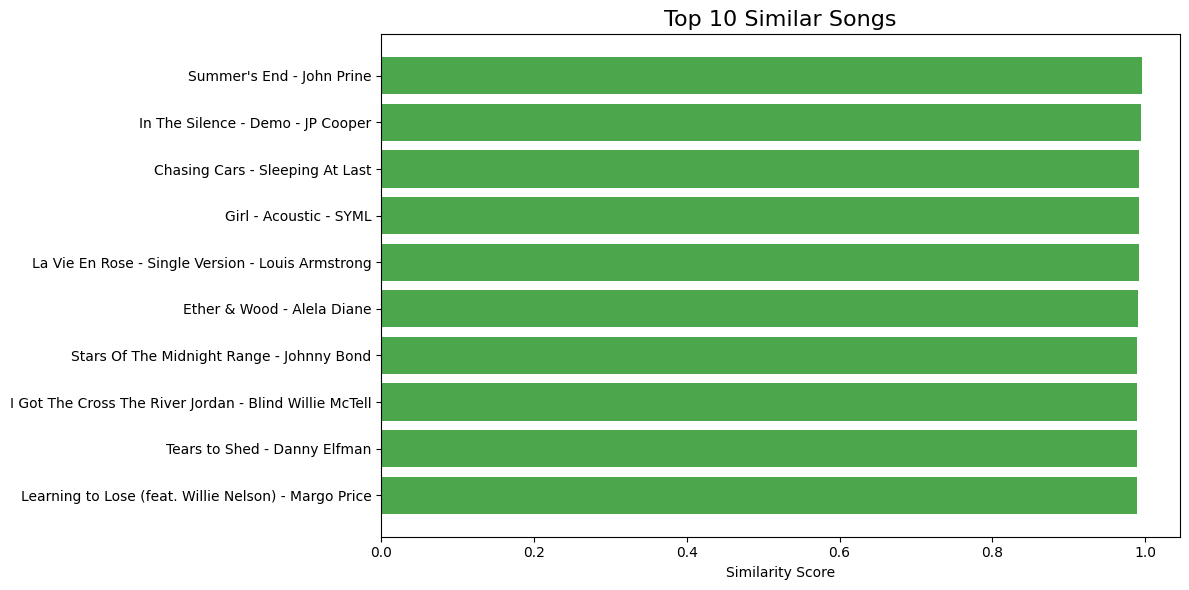

✅ Song recommendation chart saved!


In [6]:
# ===== SONG RECOMMENDATION VISUALIZATION =====
import matplotlib.pyplot as plt

result = recommend_by_song('Love', n=10)

if result is not None:
    plt.figure(figsize=(12, 6))
    plt.barh(result['track_name'] + ' - ' + result['artist_name'],
             result['similarity_score'],
             color='green', alpha=0.7)
    plt.xlabel('Similarity Score')
    plt.title('Top 10 Similar Songs', fontsize=16)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('song_recommendations.png')
    plt.show()
    print("✅ Song recommendation chart saved!")